In [1]:
import torch
import torch.nn as nn

from CvT import CvT
from dataset import CustomDataset

torch.Size([6, 37])


In [2]:
DEVICE = torch.device("cuda")
DATA_DIR = "./data"

In [3]:
from torchvision import transforms
from torch.utils.data import random_split

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataset = CustomDataset(root_dir=DATA_DIR, annotation_file=f"{DATA_DIR}/annotations/list.txt", transform=transform)

print(f'Dataset size: {len(dataset)}')
for i in range(2):
    image, label = dataset[i]
    print(f'Sample {i}: Image shape: {image.shape}, Label: {label}')
    # label = correct index

Dataset size: 7349
Sample 0: Image shape: torch.Size([3, 224, 224]), Label: 0
Sample 1: Image shape: torch.Size([3, 224, 224]), Label: 0


In [4]:
from tqdm import tqdm
from tqdm import trange

In [5]:
def train_fn(train_loader, model, optimizer, loss_fn, show_progress=False):
    loop = tqdm(train_loader, leave=True) if show_progress else train_loader
    losses = []

    for _, (img, label) in enumerate(loop):
        img = img.to(DEVICE)
        label = label.to(DEVICE)
        out = model(img)
        
        loss = loss_fn(out, label)
        losses.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if show_progress:
            loop.set_postfix(loss=loss.item())

    mean_loss = sum(losses) / len(losses)
    return mean_loss

In [6]:
def validate(loader, model, loss_fn, show_progress=False):
    model.eval()
    loop = tqdm(loader, leave=True) if show_progress else loader
    losses = []

    with torch.no_grad():
        for _, (img, label) in enumerate(loop):
            img = img.to(DEVICE)
            label = label.to(DEVICE)
            out = model(img)
            loss = loss_fn(out, label)
            losses.append(loss.item())

            if show_progress:
                loop.set_postfix(loss=loss.item())

    mean_loss = sum(losses) / len(losses)
    model.train()
    return mean_loss

In [7]:
BATCH_SIZE = 38

WD = 0.1
MOMENTUM = 0.9
LR = 2e-4

In [8]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

In [9]:
model = CvT(img_ch=3,
            attn_drop=0.1, proj_drop=0.2, mlp_drop=0.3,
            depth1=1, depth2=1, depth3=2,
            # Conv Embadding parameters
            k1=7, c1=64, s1=4, k2=3, c2=128, s2=2, k3=3, c3=256, s3=2,
            # Conv Proj parameters
            kp1=3, kp2=3, kp3=3,
            # MHSA parameters
            H1=1, H2=2, H3=4,
            # MLP parameters
            R1=4, R2=4, R3=4, num_classes=37)
model = model.to(DEVICE)

adamw = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
sgd = torch.optim.SGD(model.parameters(), lr=LR, momentum=MOMENTUM, weight_decay=WD)
optim = sgd 

loss = nn.CrossEntropyLoss()

In [10]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params}")

Trainable parameters: 2242277


In [11]:
EPOCHS = 40

In [12]:
# 1. Overfit on small dataset
# a = BATCH_SIZE * 50
# b = BATCH_SIZE * 10
# small_dataset, val_small_dataset, _ = random_split(dataset, [a, b, len(dataset) - (a+b)])
# train_loader = torch.utils.data.DataLoader(small_dataset, batch_size=BATCH_SIZE, shuffle=True)
# val_loader = torch.utils.data.DataLoader(val_small_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [13]:
from IPython.display import clear_output
import matplotlib.pyplot as plt
import os

In [ ]:
train_losses = []
val_losses = []
best_val_loss = float('inf')
best_model_path = None

for epoch in trange(EPOCHS, desc="Training"):
    train_loss = train_fn(train_loader, model, optim, loss)
    val_loss = validate(val_loader, model, loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), f"{epoch + 1}_{round(val_loss, 4)}.pt")
        if best_model_path is not None and os.path.exists(best_model_path):
            os.remove(best_model_path)
        best_model_path = f"{epoch + 1}_{round(val_loss, 4)}.pt"

    # Live plot in Jupyter
    clear_output(wait=True)
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

# Testing

In [14]:
trained_model = CvT(img_ch=3,
            attn_drop=0.1, proj_drop=0.2, mlp_drop=0.3,
            depth1=1, depth2=1, depth3=2,
            # Conv Embadding parameters
            k1=7, c1=64, s1=4, k2=3, c2=128, s2=2, k3=3, c3=256, s3=2,
            # Conv Proj parameters
            kp1=3, kp2=3, kp3=3,
            # MHSA parameters
            H1=1, H2=2, H3=4,
            # MLP parameters
            R1=4, R2=4, R3=4, num_classes=37)
state_dict = torch.load("./19_3.2852.pt", weights_only=True, map_location=DEVICE)
trained_model.load_state_dict(state_dict)
trained_model = model.to(DEVICE)
trained_model.eval()

CvT(
  (embed1): ConvTokenEmbedding(
    (conv_layer): Conv2d(3, 64, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
    (layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  )
  (blocks1): ModuleList(
    (0): ConvTransformerBlock(
      (q_dw_separable_conv_layer): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): GELU(approximate='none')
        (3): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
        (4): GELU(approximate='none')
      )
      (k_dw_separable_conv_layer): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=64)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): GELU(approximate='none')
        (3): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
        (4): GELU(approximate='none')
   

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0322802..2.64].


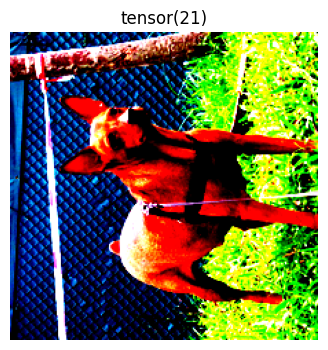

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8096584..2.3959913].


10


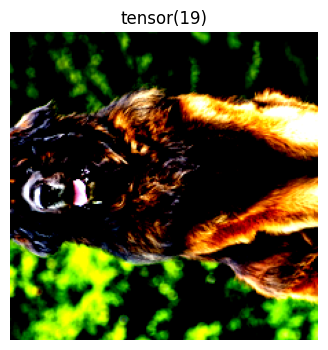

5


In [16]:
def show_image(img_tensor, title=None):
    img = img_tensor.squeeze(0)
    img = img.transpose(0,2)
    img = img.detach().cpu()

    plt.figure(figsize=(4,4))
    plt.imshow(img.numpy())
    plt.axis('off')
    if title:
        plt.title(title)
    plt.show()

softmax = torch.nn.Softmax(dim=1)
for _ in range(2):
    i = torch.randint(low=0, high=len(dataset), size=(1,)).item()
    img, label = dataset[i]
    img = img.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = trained_model(img)
        probs = softmax(logits)
        res = torch.max(probs, dim=1)[1].item()
    
    show_image(img, title=label)
    print(res)